# Benefit-area mapping for storm-system alternatives

This example computes a baseline and three proposed conditions with HEC-RAS 7.0:

1. a four-conduit capacity upgrade selected from baseline flow, velocity, connectivity, and node-depth diagnostics; and
2. a second identical pump represented by doubling the pump-group HQ-curve flow ordinates; and
3. the conduit and pump upgrades applied together.

Each alternative receives its own hydraulic comparison, BenefitArea raster and optional simplified polygon, adverse-depth screen, and building-footprint overlay. A final common-scale figure compares all three alternatives directly. Depth is the default mapping input; WSE generation is optional because it adds processing time.

## Workflow and configuration

The workflow requires a registered, georeferenced, one-band terrain GeoTIFF shared by all plans. If a consolidated terrain must be created or registered, use `RasTerrain.vrt_to_tiff()`, `RasTerrain.create_terrain_from_rasters()` or `RasTerrain.create_terrain_hdf()`, followed by `RasMap.add_terrain_layer()` and `RasMap.associate_geometry_layers()`.

Delete `working/612_benefit_area_analysis` to force a clean end-to-end extraction and hydraulic rerun. Otherwise, extraction and completed HEC-RAS results are reused while the analysis and figures are regenerated.

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from IPython.display import display
from rasterio.features import shapes
from shapely.geometry import shape

from ras_commander import (
    BenefitAreaConfig,
    GeomPipeNetwork,
    HdfPipe,
    HdfPump,
    HdfResultsPlan,
    RasBenefits,
    RasCmdr,
    RasExamples,
    RasGeo,
    RasPlan,
    RasProcess,
    init_ras_project,
    ras,
)

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "examples":
    REPO_ROOT = REPO_ROOT.parent

WORK_ROOT = REPO_ROOT / "working" / "612_benefit_area_analysis"
PROJECT_SUFFIX = "612_benefit_area"
PROJECT_DIR = WORK_ROOT / f"Davis_{PROJECT_SUFFIX}"
PROJECT_FILE = PROJECT_DIR / "DavisStormSystem.prj"
BUILDING_PMTILES = REPO_ROOT / "examples" / "data" / "davis_building_footprints.pmtiles"
BUILDING_PARQUET = REPO_ROOT / "examples" / "data" / "davis_building_footprints.parquet"
RAS_VERSION = "7.0"
NUM_CORES = 4

BASELINE_PLAN = "02"
BASELINE_GEOMETRY = "02"
PIPE_PLAN = "01"
PIPE_GEOMETRY = "01"
PUMP_PLAN = "03"
PUMP_GEOMETRY = "03"
COMBINED_PLAN = "04"
COMBINED_GEOMETRY = "04"

PIPE_OUTPUT_DIR = Path("BenefitArea") / "p02-to-p01-pipe-upgrade"
PUMP_OUTPUT_DIR = Path("BenefitArea") / "p02-to-p03-second-pump"
COMBINED_OUTPUT_DIR = Path("BenefitArea") / "p02-to-p04-pipe-and-pump-upgrade"

INCLUDE_WSE = False
MINIMUM_REGION_PIXELS = 16
SIMPLIFY_POLYGON_EDGES = True
FLOOD_MIN_DEPTH_FT = 0.05
BENEFIT_MIN_DEPTH_FT = 0.25
ADVERSE_IMPACT_THRESHOLD_FT = 0.05

SELECTED_CONDUITS = ["3", "97", "98", "119"]
CONDUIT_TARGETS = {
    "3": (2.5, 2.5),
    "97": (4.5, 4.5),
    "98": (4.5, 4.5),
    "119": (6.0, 6.0),
}
PUMP_GROUP_NAME = "Pump Station #1"

WORK_ROOT.mkdir(parents=True, exist_ok=True)
print(f"Working folder: {WORK_ROOT}")

Working folder: C:\Users\bill\.config\superpowers\worktrees\ras-commander\codex-benefit-area\working\612_benefit_area_analysis


## 1. Extract and initialize the project

In [2]:
project_extracted = False
if PROJECT_FILE.exists():
    project_path = PROJECT_DIR
    print("Extraction skipped: project already exists.")
else:
    project_path = RasExamples.extract_project(
        "Davis",
        output_path=WORK_ROOT,
        suffix=PROJECT_SUFFIX,
    )
    if project_path.resolve() != PROJECT_DIR.resolve():
        raise RuntimeError(f"Unexpected extraction path: {project_path}")
    project_extracted = True
    print(f"Project extracted: {project_path}")

init_ras_project(project_path, RAS_VERSION)
summary_columns = [
    name for name in ("plan_number", "Plan Title", "geometry_number")
    if name in ras.plan_df.columns
]
display(ras.plan_df[summary_columns])

Extraction skipped: project already exists.


2026-07-18 09:16:29 - ras_commander.RasPrj - INFO - ras-commander v0.99.0 | An open-source project of CLB Engineering Corporation (https://clbengineering.com/) | Docs: https://rascommander.info | GitHub: https://github.com/gpt-cmdr/ras-commander


2026-07-18 09:16:29 - ras_commander.RasPrj - INFO - Project initialized: DavisStormSystem


2026-07-18 09:16:29 - ras_commander.RasPrj - INFO - Using HEC-RAS version 7.0


2026-07-18 09:16:29 - ras_commander.RasPrj - INFO - 
═══════════════════════════════════════════════════════════════════════
ras-commander | HEC-RAS Automation Library
Docs: https://rascommander.info/
Repo: https://github.com/gpt-cmdr/ras-commander
LLM agents: https://rascommander.info/llms.txt
═══════════════════════════════════════════════════════════════════════

PROJECT DATAFRAMES (single source of truth — use these, not file globbing):
  ras.plan_df        Plans, HDF paths, geometry/flow associations
  ras.geom_df        Geometry files and HDF preprocessor paths
  ras.flow_df        Steady flow files
  ras.unsteady_df    Unsteady flow files and configurations
  ras.boundaries_df  Boundary conditions (type, name, location)
  ras.results_df     Lightweight HDF results summaries
  ras.rasmap_df      RASMapper layers, terrain, land cover paths

KEY APIS (static classes — call directly, never instantiate):
  Execution:    RasCmdr.compute_plan() / compute_parallel() / compute_test_mode(

,plan_number,Plan Title,geometry_number
0,02,Full System ROM with Pump,02
1,01,Conduit Capacity Upgrade,01
2,03,Second Pump,03
3,04,Conduit Capacity and Second Pump,04


## 2. Reusable compute and analysis helpers

In [3]:
def review_compute_messages(plan_number: str, label: str) -> dict:
    messages = HdfResultsPlan.get_compute_messages(plan_number)
    lines = [line.strip() for line in messages.splitlines() if line.strip()]
    if not any("Complete Process" in line for line in lines):
        raise RuntimeError(f"{label} does not contain a completed-process marker")
    fatal = [line for line in lines if line.upper().startswith(("ERROR:", "FATAL:"))]
    if fatal:
        raise RuntimeError(f"{label} compute errors:\n" + "\n".join(fatal))
    warnings = [line for line in lines if "WARNING" in line.upper()]
    runtime = HdfResultsPlan.get_runtime_data(plan_number)
    process_hours = (
        float(runtime.iloc[0]["Complete Process (hr)"])
        if runtime is not None and not runtime.empty else np.nan
    )
    print(f"{label}: complete; runtime={process_hours:.3f} hr; warnings={len(warnings)}")
    return {"runtime_hours": process_hours, "warning_count": len(warnings)}


def compute_plan_stage(plan_number: str, label: str, *, inputs_changed=False) -> dict:
    result_hdf = PROJECT_DIR / f"DavisStormSystem.p{plan_number}.hdf"
    before = result_hdf.stat().st_mtime_ns if result_hdf.exists() else None
    result = RasCmdr.compute_plan(
        plan_number,
        num_cores=NUM_CORES,
        clear_geompre=inputs_changed,
        force_rerun=inputs_changed,
        skip_existing=not inputs_changed,
        verify=True,
    )
    if not result.success and inputs_changed:
        messages = HdfResultsPlan.get_compute_messages(plan_number)
        if "HDF_ERROR trying to use HDF output file" in messages and result_hdf.exists():
            print(f"{label}: geometry tables rebuilt; retrying with a fresh result HDF.")
            result_hdf.unlink()
            result = RasCmdr.compute_plan(
                plan_number,
                num_cores=NUM_CORES,
                clear_geompre=False,
                force_rerun=True,
                skip_existing=False,
                verify=True,
            )
    if not result.success:
        raise RuntimeError(f"{label} compute failed")
    after = result_hdf.stat().st_mtime_ns if result_hdf.exists() else None
    executed = before is None or before != after
    print(f"{label} compute stage: {'executed' if executed else 'skipped (completed result exists)'}")
    return {"executed": executed, **review_compute_messages(plan_number, label)}


def finite_abs_max(values) -> float:
    array = np.asarray(values, dtype=float)
    finite = np.isfinite(array)
    return float(np.max(np.abs(array[finite]))) if finite.any() else np.nan


def pipe_qv_summary(plan_number: str) -> pd.DataFrame:
    conduits = HdfPipe.get_pipe_conduits(plan_number, crs=None).reset_index(drop=True)
    variables = {
        name: HdfPipe.get_pipe_network_timeseries(plan_number, name)
        for name in ("Pipes/Pipe Flow US", "Pipes/Pipe Flow DS", "Pipes/Vel US", "Pipes/Vel DS")
    }
    rows = []
    for location, conduit in conduits.iterrows():
        rows.append({
            "conduit": str(conduit["Name"]).strip(),
            "us_node": str(conduit["US Node"]).strip(),
            "ds_node": str(conduit["DS Node"]).strip(),
            "rise_ft": float(conduit["Rise"]),
            "span_ft": float(conduit["Span"]),
            "max_abs_flow_cfs": max(
                finite_abs_max(variables["Pipes/Pipe Flow US"][:, location]),
                finite_abs_max(variables["Pipes/Pipe Flow DS"][:, location]),
            ),
            "max_abs_velocity_ft_s": max(
                finite_abs_max(variables["Pipes/Vel US"][:, location]),
                finite_abs_max(variables["Pipes/Vel DS"][:, location]),
            ),
        })
    return pd.DataFrame(rows)


def node_depth_summary(plan_number: str) -> pd.DataFrame:
    nodes = HdfPipe.get_pipe_nodes(plan_number, crs=None).reset_index(drop=True)
    depth = HdfPipe.get_pipe_network_timeseries(plan_number, "Nodes/Depth")
    return pd.DataFrame({
        "node": nodes["Name"].astype(str).str.strip(),
        "max_depth_ft": [finite_abs_max(depth[:, index]) for index in range(len(nodes))],
    })


def read_map_raster(path: Path, *, mask_zero=False):
    with rasterio.open(path) as src:
        data = src.read(1, masked=True)
        if mask_zero:
            data = np.ma.masked_where(np.asarray(data) == 0, data)
        extent = (src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top)
        return data, extent, src.crs, src.transform, src.profile.copy()

## 3. Compute the baseline and select a connected conduit path

In [4]:
baseline_compute = compute_plan_stage(
    BASELINE_PLAN, "Baseline", inputs_changed=project_extracted
)
baseline_qv = pipe_qv_summary(BASELINE_PLAN)
baseline_nodes = node_depth_summary(BASELINE_PLAN)

selection = baseline_qv[baseline_qv["conduit"].isin(SELECTED_CONDUITS)].copy()
selection["chain_order"] = selection["conduit"].map(
    {name: order for order, name in enumerate(SELECTED_CONDUITS)}
)
selection = selection.sort_values("chain_order")
selection = selection.merge(
    baseline_nodes.rename(columns={"node": "us_node", "max_depth_ft": "us_node_max_depth_ft"}),
    on="us_node",
    how="left",
)
selection.to_csv(WORK_ROOT / "baseline_selected_conduit_diagnostics.csv", index=False)
display(selection[[
    "conduit", "us_node", "ds_node", "rise_ft",
    "max_abs_flow_cfs", "max_abs_velocity_ft_s", "us_node_max_depth_ft",
]])

2026-07-18 09:16:29 - ras_commander.RasCmdr - INFO - Skipping plan 02: HDF results already exist with 'Complete Process'


Baseline compute stage: skipped (completed result exists)
Baseline: complete; runtime=0.085 hr; warnings=0


,conduit,us_node,ds_node,rise_ft,max_abs_flow_cfs,max_abs_velocity_ft_s,us_node_max_depth_ft
0,3,P12-DI011,P12-DMH005,1.25,2.498052,7.350999,0.239808
1,97,P12-DMH005,P12-DMH008,3.00,6.012918,2.294528,9.111440
2,98,P12-DMH008,P12-DMH010,3.00,6.912639,2.863071,5.686985
3,119,P12-DMH010,P12-DMH013,4.00,17.689779,2.660488,3.282387


## 4. Build and show the pipe-only alternative

The selected path starts with the baseline network's highest-velocity inlet connection and continues through three downstream conduits. The proposed diameters are absolute, rerun-safe targets.

2026-07-18 09:16:29 - ras_commander.RasPrj - INFO - ras-commander v0.99.0 | An open-source project of CLB Engineering Corporation (https://clbengineering.com/) | Docs: https://rascommander.info | GitHub: https://github.com/gpt-cmdr/ras-commander


2026-07-18 09:16:29 - ras_commander.RasPrj - INFO - Project initialized: DavisStormSystem


2026-07-18 09:16:29 - ras_commander.RasPrj - INFO - Using HEC-RAS version 7.0


2026-07-18 09:16:29 - ras_commander.RasPrj - INFO - 
═══════════════════════════════════════════════════════════════════════
ras-commander | HEC-RAS Automation Library
Docs: https://rascommander.info/
Repo: https://github.com/gpt-cmdr/ras-commander
LLM agents: https://rascommander.info/llms.txt
═══════════════════════════════════════════════════════════════════════

PROJECT DATAFRAMES (single source of truth — use these, not file globbing):
  ras.plan_df        Plans, HDF paths, geometry/flow associations
  ras.geom_df        Geometry files and HDF preprocessor paths
  ras.flow_df        Steady flow files
  ras.unsteady_df    Unsteady flow files and configurations
  ras.boundaries_df  Boundary conditions (type, name, location)
  ras.results_df     Lightweight HDF results summaries
  ras.rasmap_df      RASMapper layers, terrain, land cover paths

KEY APIS (static classes — call directly, never instantiate):
  Execution:    RasCmdr.compute_plan() / compute_parallel() / compute_test_mode(

Pipe-only alternative: configuration already current.


,Name,old_rise,old_span,new_rise,new_span,changed
0,3,2.5,2.5,2.5,2.5,False
1,97,4.5,4.5,4.5,4.5,False
2,98,4.5,4.5,4.5,4.5,False
3,119,6.0,6.0,6.0,6.0,False


Building overlay: 7,363 footprints; PMTiles layer 'buildings' at C:\Users\bill\.config\superpowers\worktrees\ras-commander\codex-benefit-area\examples\data\davis_building_footprints.pmtiles


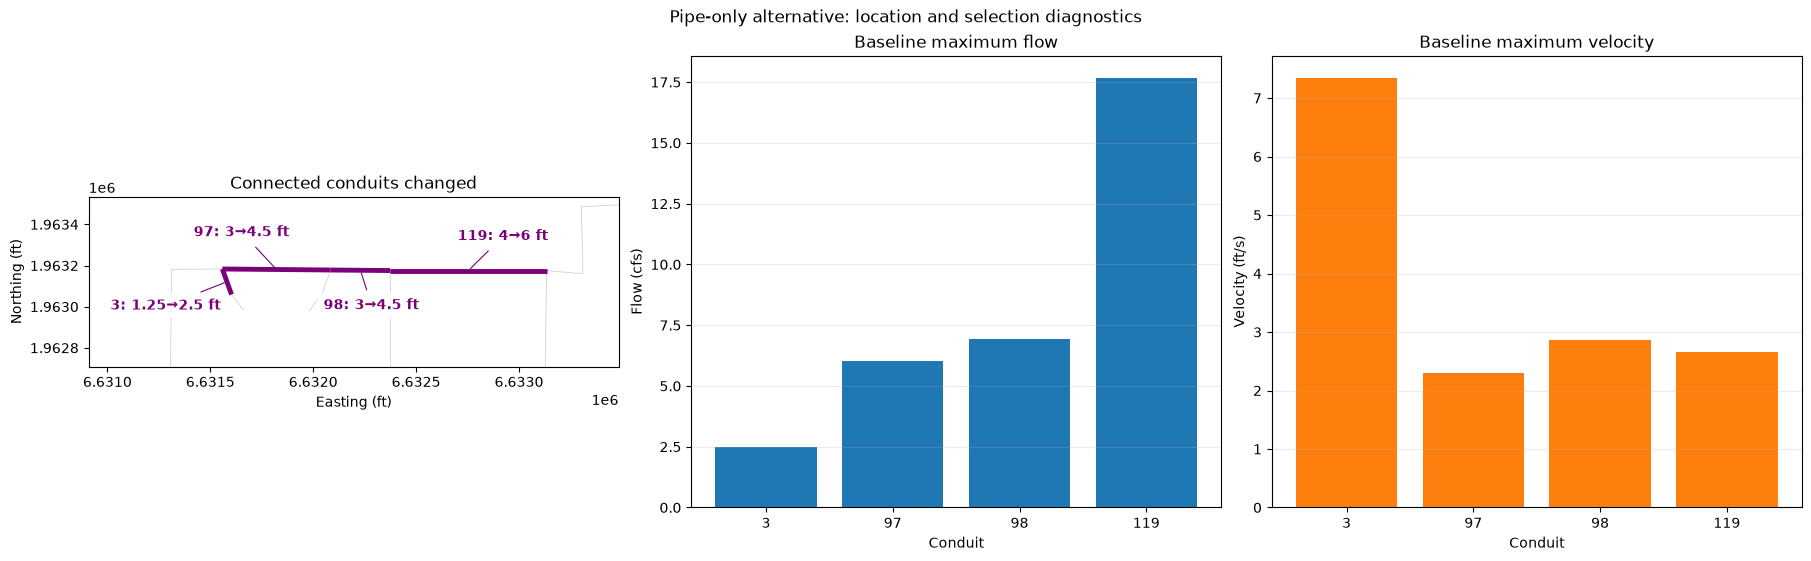

In [5]:
project_stem = ras.project_name
pipe_geom_file = PROJECT_DIR / f"{project_stem}.g{PIPE_GEOMETRY}"
pipe_plan_file = PROJECT_DIR / f"{project_stem}.p{PIPE_PLAN}"
pipe_created = False

if not pipe_geom_file.exists():
    new_geom = RasGeo.clone_geom(BASELINE_GEOMETRY, new_title="Conduit Capacity Upgrade")
    if new_geom != PIPE_GEOMETRY:
        raise RuntimeError(f"Expected geometry {PIPE_GEOMETRY}; created {new_geom}")
    pipe_created = True

conduit_changes = GeomPipeNetwork.set_conduit_dimensions(pipe_geom_file, CONDUIT_TARGETS)

if not pipe_plan_file.exists():
    new_plan = RasPlan.clone_plan(
        BASELINE_PLAN,
        new_shortid="PipeUpgrade",
        new_title="Conduit Capacity Upgrade",
        geometry=PIPE_GEOMETRY,
        num_cores=NUM_CORES,
    )
    if new_plan != PIPE_PLAN:
        raise RuntimeError(f"Expected plan {PIPE_PLAN}; created {new_plan}")
    pipe_created = True

init_ras_project(PROJECT_DIR, RAS_VERSION)
pipe_inputs_changed = bool(pipe_created or conduit_changes["changed"].any())
print(
    "Pipe-only alternative: "
    + ("created or updated." if pipe_inputs_changed else "configuration already current.")
)
display(conduit_changes)

terrain_hdf = PROJECT_DIR / "Terrain" / "Terrain (1).hdf"
terrain_tif = RasBenefits.get_registered_terrain_source(terrain_hdf)
with rasterio.open(terrain_tif) as terrain_src:
    if terrain_src.count != 1:
        raise ValueError("Benefit analysis requires a one-band terrain GeoTIFF")
    scenario_crs = terrain_src.crs
    terrain_resolution = max(abs(value) for value in terrain_src.res)

if not BUILDING_PMTILES.exists() or not BUILDING_PARQUET.exists():
    raise FileNotFoundError("The Davis building-footprint example assets are missing")
building_footprints = gpd.read_parquet(BUILDING_PARQUET).to_crs(scenario_crs)
print(
    f"Building overlay: {len(building_footprints):,} footprints; "
    f"PMTiles layer 'buildings' at {BUILDING_PMTILES}"
)

pipe_network = HdfPipe.get_pipe_conduits(BASELINE_PLAN, crs=scenario_crs).copy()
pipe_network["conduit"] = pipe_network["Name"].astype(str).str.strip()
changed_pipe_assets = pipe_network[pipe_network["conduit"].isin(SELECTED_CONDUITS)].copy()
changed_pipe_assets["chain_order"] = changed_pipe_assets["conduit"].map(
    {name: order for order, name in enumerate(SELECTED_CONDUITS)}
)
changed_pipe_assets = changed_pipe_assets.sort_values("chain_order")
changed_pipe_assets["baseline_diameter_ft"] = changed_pipe_assets["Rise"].astype(float)
changed_pipe_assets["proposed_diameter_ft"] = changed_pipe_assets["conduit"].map(
    {name: dimensions[0] for name, dimensions in CONDUIT_TARGETS.items()}
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), constrained_layout=True)
pipe_network.plot(ax=axes[0], color="#bdbdbd", linewidth=0.55, alpha=0.75)
changed_pipe_assets.plot(ax=axes[0], color="#7a0177", linewidth=3.5, zorder=4)
definition_label_offsets = {
    "3": (-44, -20), "97": (-25, 24), "98": (8, -28), "119": (25, 22)
}
for row in changed_pipe_assets.itertuples():
    midpoint = row.Polyline.interpolate(0.5, normalized=True)
    axes[0].annotate(
        f"{row.conduit}: {row.baseline_diameter_ft:g}→{row.proposed_diameter_ft:g} ft",
        xy=(midpoint.x, midpoint.y),
        xytext=definition_label_offsets[row.conduit], textcoords="offset points",
        ha="center", color="#7a0177", weight="bold",
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.85},
        arrowprops={"arrowstyle": "-", "color": "#7a0177", "linewidth": 0.8},
    )
min_x, min_y, max_x, max_y = changed_pipe_assets.total_bounds
axes[0].set_xlim(min_x - 650, max_x + 350)
axes[0].set_ylim(min_y - 350, max_y + 350)
axes[0].set_aspect("equal")
axes[0].set_title("Connected conduits changed")
axes[0].set_xlabel("Easting (ft)")
axes[0].set_ylabel("Northing (ft)")

plot_selection = selection.set_index("conduit").loc[SELECTED_CONDUITS].reset_index()
positions = np.arange(len(plot_selection))
axes[1].bar(positions, plot_selection["max_abs_flow_cfs"], color="tab:blue")
axes[1].set_xticks(positions, plot_selection["conduit"])
axes[1].set_title("Baseline maximum flow")
axes[1].set_xlabel("Conduit")
axes[1].set_ylabel("Flow (cfs)")
axes[1].grid(axis="y", alpha=0.25)
axes[2].bar(positions, plot_selection["max_abs_velocity_ft_s"], color="tab:orange")
axes[2].set_xticks(positions, plot_selection["conduit"])
axes[2].set_title("Baseline maximum velocity")
axes[2].set_xlabel("Conduit")
axes[2].set_ylabel("Velocity (ft/s)")
axes[2].grid(axis="y", alpha=0.25)
fig.suptitle("Pipe-only alternative: location and selection diagnostics")
fig.savefig(WORK_ROOT / "pipe_alternative_definition.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Build and show the second-pump alternative

A second identical pump in parallel is represented by retaining each head ordinate and doubling each HQ-curve flow ordinate. This is independent of the conduit alternative.

2026-07-18 09:16:32 - ras_commander.RasPrj - INFO - ras-commander v0.99.0 | An open-source project of CLB Engineering Corporation (https://clbengineering.com/) | Docs: https://rascommander.info | GitHub: https://github.com/gpt-cmdr/ras-commander


2026-07-18 09:16:32 - ras_commander.RasPrj - INFO - Project initialized: DavisStormSystem


2026-07-18 09:16:32 - ras_commander.RasPrj - INFO - Using HEC-RAS version 7.0


2026-07-18 09:16:32 - ras_commander.RasPrj - INFO - 
═══════════════════════════════════════════════════════════════════════
ras-commander | HEC-RAS Automation Library
Docs: https://rascommander.info/
Repo: https://github.com/gpt-cmdr/ras-commander
LLM agents: https://rascommander.info/llms.txt
═══════════════════════════════════════════════════════════════════════

PROJECT DATAFRAMES (single source of truth — use these, not file globbing):
  ras.plan_df        Plans, HDF paths, geometry/flow associations
  ras.geom_df        Geometry files and HDF preprocessor paths
  ras.flow_df        Steady flow files
  ras.unsteady_df    Unsteady flow files and configurations
  ras.boundaries_df  Boundary conditions (type, name, location)
  ras.results_df     Lightweight HDF results summaries
  ras.rasmap_df      RASMapper layers, terrain, land cover paths

KEY APIS (static classes — call directly, never instantiate):
  Execution:    RasCmdr.compute_plan() / compute_parallel() / compute_test_mode(

Second-pump alternative: configuration already current.


,group_name,head,old_flow,new_flow,changed
0,Pump Station #1,2.0,140.0,140.0,False
1,Pump Station #1,4.0,120.0,120.0,False
2,Pump Station #1,6.0,110.0,110.0,False
3,Pump Station #1,8.0,100.0,100.0,False
4,Pump Station #1,14.0,80.0,80.0,False
5,Pump Station #1,16.0,50.0,50.0,False


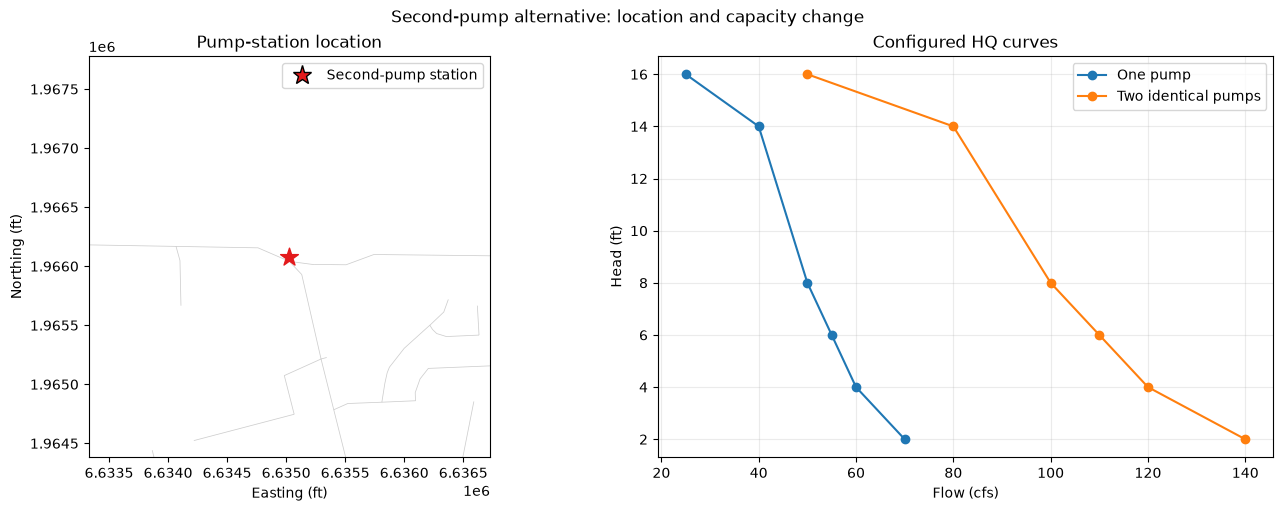

In [6]:
pump_geom_file = PROJECT_DIR / f"{project_stem}.g{PUMP_GEOMETRY}"
pump_plan_file = PROJECT_DIR / f"{project_stem}.p{PUMP_PLAN}"
pump_created = False

if not pump_geom_file.exists():
    new_geom = RasGeo.clone_geom(BASELINE_GEOMETRY, new_title="Second Pump")
    if new_geom != PUMP_GEOMETRY:
        raise RuntimeError(f"Expected geometry {PUMP_GEOMETRY}; created {new_geom}")
    pump_created = True

baseline_pump_groups = HdfPump.get_pump_groups(BASELINE_PLAN)
baseline_curve = np.asarray(
    baseline_pump_groups.loc[
        baseline_pump_groups["Name"] == PUMP_GROUP_NAME, "efficiency_curve"
    ].iloc[0],
    dtype=float,
)
second_pump_curve = baseline_curve.copy()
second_pump_curve[:, 1] *= 2.0
pump_changes = GeomPipeNetwork.set_pump_group_hq_curve(
    pump_geom_file, PUMP_GROUP_NAME, second_pump_curve
)

if not pump_plan_file.exists():
    new_plan = RasPlan.clone_plan(
        BASELINE_PLAN,
        new_shortid="SecondPump",
        new_title="Second Pump",
        geometry=PUMP_GEOMETRY,
        num_cores=NUM_CORES,
    )
    if new_plan != PUMP_PLAN:
        raise RuntimeError(f"Expected plan {PUMP_PLAN}; created {new_plan}")
    pump_created = True

init_ras_project(PROJECT_DIR, RAS_VERSION)
pump_inputs_changed = bool(pump_created or pump_changes["changed"].any())
print(
    "Second-pump alternative: "
    + ("created or updated." if pump_inputs_changed else "configuration already current.")
)
display(pump_changes)

pump_assets = HdfPump.get_pump_stations(BASELINE_PLAN).to_crs(scenario_crs)
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
pipe_network.plot(ax=axes[0], color="#bdbdbd", linewidth=0.55, alpha=0.75)
pump_assets.plot(ax=axes[0], color="#e31a1c", marker="*", markersize=180, zorder=5)
px, py = pump_assets.geometry.iloc[0].x, pump_assets.geometry.iloc[0].y
axes[0].set_xlim(px - 1700, px + 1700)
axes[0].set_ylim(py - 1700, py + 1700)
axes[0].set_aspect("equal")
axes[0].set_title("Pump-station location")
axes[0].set_xlabel("Easting (ft)")
axes[0].set_ylabel("Northing (ft)")
axes[0].legend(handles=[Line2D([0], [0], marker="*", color="none", markerfacecolor="#e31a1c", markersize=14, label="Second-pump station")])
axes[1].plot(baseline_curve[:, 1], baseline_curve[:, 0], marker="o", label="One pump")
axes[1].plot(second_pump_curve[:, 1], second_pump_curve[:, 0], marker="o", label="Two identical pumps")
axes[1].set_xlabel("Flow (cfs)")
axes[1].set_ylabel("Head (ft)")
axes[1].set_title("Configured HQ curves")
axes[1].grid(alpha=0.25)
axes[1].legend()
fig.suptitle("Second-pump alternative: location and capacity change")
fig.savefig(WORK_ROOT / "second_pump_alternative_definition.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Build and show the combined pipe-and-pump alternative

The third alternative applies the same four conduit targets and the same doubled pump HQ curve to a fresh clone of the baseline geometry. It therefore represents both improvements together without inheriting results from either independent alternative.

2026-07-18 09:16:33 - ras_commander.RasPrj - INFO - ras-commander v0.99.0 | An open-source project of CLB Engineering Corporation (https://clbengineering.com/) | Docs: https://rascommander.info | GitHub: https://github.com/gpt-cmdr/ras-commander


2026-07-18 09:16:33 - ras_commander.RasPrj - INFO - Project initialized: DavisStormSystem


2026-07-18 09:16:33 - ras_commander.RasPrj - INFO - Using HEC-RAS version 7.0


2026-07-18 09:16:33 - ras_commander.RasPrj - INFO - 
═══════════════════════════════════════════════════════════════════════
ras-commander | HEC-RAS Automation Library
Docs: https://rascommander.info/
Repo: https://github.com/gpt-cmdr/ras-commander
LLM agents: https://rascommander.info/llms.txt
═══════════════════════════════════════════════════════════════════════

PROJECT DATAFRAMES (single source of truth — use these, not file globbing):
  ras.plan_df        Plans, HDF paths, geometry/flow associations
  ras.geom_df        Geometry files and HDF preprocessor paths
  ras.flow_df        Steady flow files
  ras.unsteady_df    Unsteady flow files and configurations
  ras.boundaries_df  Boundary conditions (type, name, location)
  ras.results_df     Lightweight HDF results summaries
  ras.rasmap_df      RASMapper layers, terrain, land cover paths

KEY APIS (static classes — call directly, never instantiate):
  Execution:    RasCmdr.compute_plan() / compute_parallel() / compute_test_mode(

Combined pipe-and-pump alternative: configuration already current.


,Name,old_rise,old_span,new_rise,new_span,changed
0,3,2.5,2.5,2.5,2.5,False
1,97,4.5,4.5,4.5,4.5,False
2,98,4.5,4.5,4.5,4.5,False
3,119,6.0,6.0,6.0,6.0,False


,group_name,head,old_flow,new_flow,changed
0,Pump Station #1,2.0,140.0,140.0,False
1,Pump Station #1,4.0,120.0,120.0,False
2,Pump Station #1,6.0,110.0,110.0,False
3,Pump Station #1,8.0,100.0,100.0,False
4,Pump Station #1,14.0,80.0,80.0,False
5,Pump Station #1,16.0,50.0,50.0,False


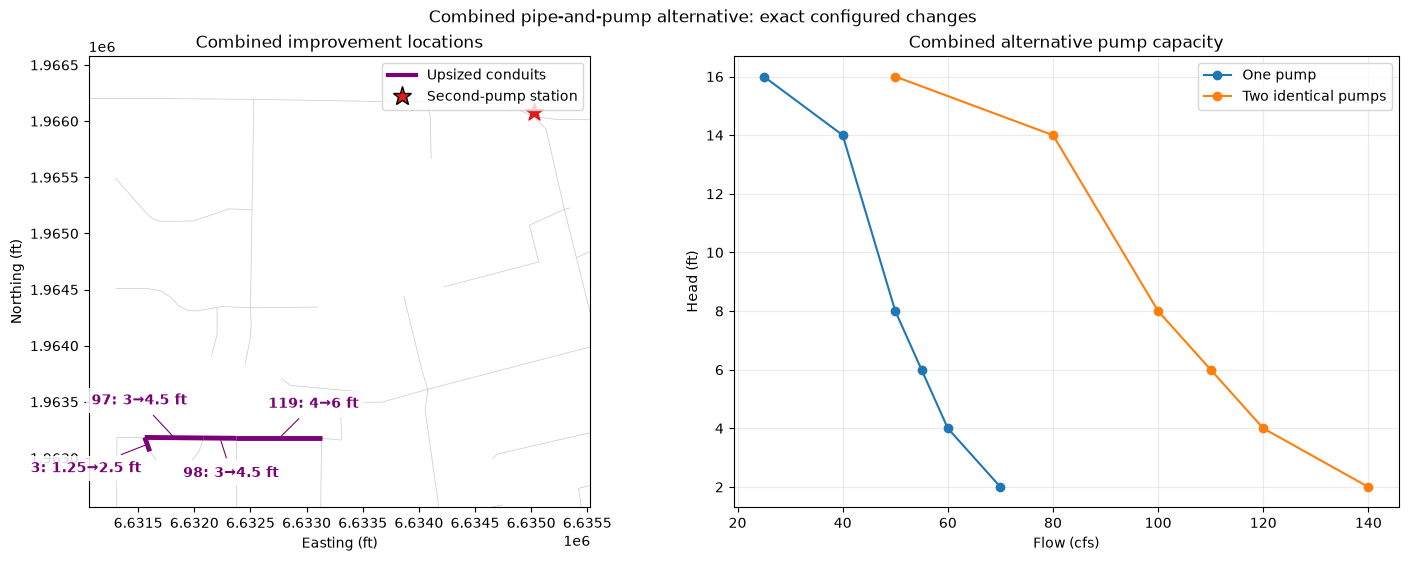

In [7]:
combined_geom_file = PROJECT_DIR / f"{project_stem}.g{COMBINED_GEOMETRY}"
combined_plan_file = PROJECT_DIR / f"{project_stem}.p{COMBINED_PLAN}"
combined_created = False

if not combined_geom_file.exists():
    new_geom = RasGeo.clone_geom(
        BASELINE_GEOMETRY, new_title="Conduit Capacity and Second Pump"
    )
    if new_geom != COMBINED_GEOMETRY:
        raise RuntimeError(
            f"Expected geometry {COMBINED_GEOMETRY}; created {new_geom}"
        )
    combined_created = True

combined_conduit_changes = GeomPipeNetwork.set_conduit_dimensions(
    combined_geom_file, CONDUIT_TARGETS
)
combined_pump_changes = GeomPipeNetwork.set_pump_group_hq_curve(
    combined_geom_file, PUMP_GROUP_NAME, second_pump_curve
)

if not combined_plan_file.exists():
    new_plan = RasPlan.clone_plan(
        BASELINE_PLAN,
        new_shortid="PipePump",
        new_title="Conduit Capacity and Second Pump",
        geometry=COMBINED_GEOMETRY,
        num_cores=NUM_CORES,
    )
    if new_plan != COMBINED_PLAN:
        raise RuntimeError(f"Expected plan {COMBINED_PLAN}; created {new_plan}")
    combined_created = True

init_ras_project(PROJECT_DIR, RAS_VERSION)
combined_inputs_changed = bool(
    combined_created
    or combined_conduit_changes["changed"].any()
    or combined_pump_changes["changed"].any()
)
print(
    "Combined pipe-and-pump alternative: "
    + ("created or updated." if combined_inputs_changed else "configuration already current.")
)
display(combined_conduit_changes)
display(combined_pump_changes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)
pipe_network.plot(ax=axes[0], color="#bdbdbd", linewidth=0.55, alpha=0.75)
changed_pipe_assets.plot(ax=axes[0], color="#7a0177", linewidth=3.5, zorder=4)
pump_assets.plot(ax=axes[0], color="#e31a1c", marker="*", markersize=180, zorder=5)
for row in changed_pipe_assets.itertuples():
    midpoint = row.Polyline.interpolate(0.5, normalized=True)
    axes[0].annotate(
        f"{row.conduit}: {row.baseline_diameter_ft:g}→{row.proposed_diameter_ft:g} ft",
        xy=(midpoint.x, midpoint.y),
        xytext=definition_label_offsets[row.conduit], textcoords="offset points",
        ha="center", color="#7a0177", weight="bold",
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.85},
        arrowprops={"arrowstyle": "-", "color": "#7a0177", "linewidth": 0.8},
    )
combined_min_x = min(changed_pipe_assets.total_bounds[0], px) - 500
combined_max_x = max(changed_pipe_assets.total_bounds[2], px) + 500
combined_min_y = min(changed_pipe_assets.total_bounds[1], py) - 500
combined_max_y = max(changed_pipe_assets.total_bounds[3], py) + 500
axes[0].set_xlim(combined_min_x, combined_max_x)
axes[0].set_ylim(combined_min_y, combined_max_y)
axes[0].set_aspect("equal")
axes[0].set_title("Combined improvement locations")
axes[0].set_xlabel("Easting (ft)")
axes[0].set_ylabel("Northing (ft)")
axes[0].legend(handles=[
    Line2D([0], [0], color="#7a0177", linewidth=3, label="Upsized conduits"),
    Line2D([0], [0], marker="*", color="none", markerfacecolor="#e31a1c",
           markersize=14, label="Second-pump station"),
])
axes[1].plot(baseline_curve[:, 1], baseline_curve[:, 0], marker="o", label="One pump")
axes[1].plot(second_pump_curve[:, 1], second_pump_curve[:, 0], marker="o", label="Two identical pumps")
axes[1].set_xlabel("Flow (cfs)")
axes[1].set_ylabel("Head (ft)")
axes[1].set_title("Combined alternative pump capacity")
axes[1].grid(alpha=0.25)
axes[1].legend()
fig.suptitle("Combined pipe-and-pump alternative: exact configured changes")
fig.savefig(WORK_ROOT / "combined_alternative_definition.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Compute all three alternatives and compare hydraulic performance

2026-07-18 09:16:35 - ras_commander.RasCmdr - INFO - Skipping plan 01: HDF results already exist with 'Complete Process'


2026-07-18 09:16:35 - ras_commander.RasCmdr - INFO - Skipping plan 03: HDF results already exist with 'Complete Process'


2026-07-18 09:16:35 - ras_commander.RasCmdr - INFO - Skipping plan 04: HDF results already exist with 'Complete Process'


Pipe-only alternative compute stage: skipped (completed result exists)
Pipe-only alternative: complete; runtime=0.092 hr; warnings=0
Second-pump alternative compute stage: skipped (completed result exists)
Second-pump alternative: complete; runtime=0.130 hr; warnings=0
Combined pipe-and-pump alternative compute stage: skipped (completed result exists)
Combined pipe-and-pump alternative: complete; runtime=0.088 hr; warnings=0


,conduit,us_node,ds_node,rise_ft,span_ft,max_abs_flow_cfs,max_abs_velocity_ft_s,condition,chain_order
3,3,P12-DI011,P12-DMH005,1.25,1.25,2.498052,7.350999,Baseline,0
15,3,P12-DI011,P12-DMH005,2.50,2.50,1.955437,4.993278,Pipe + pump,0
7,3,P12-DI011,P12-DMH005,2.50,2.50,1.833667,4.993276,Pipe only,0
11,3,P12-DI011,P12-DMH005,1.25,1.25,2.888032,7.351010,Second pump,0
2,97,P12-DMH005,P12-DMH008,3.00,3.00,6.012918,2.294528,Baseline,1
14,97,P12-DMH005,P12-DMH008,4.50,4.50,6.188016,2.251207,Pipe + pump,1
6,97,P12-DMH005,P12-DMH008,4.50,4.50,5.880278,2.251064,Pipe only,1
10,97,P12-DMH005,P12-DMH008,3.00,3.00,6.351912,2.294528,Second pump,1
1,98,P12-DMH008,P12-DMH010,3.00,3.00,6.912639,2.863071,Baseline,2
13,98,P12-DMH008,P12-DMH010,4.50,4.50,6.926834,2.832395,Pipe + pump,2


,condition,peak_flow_cfs,max_headwater_ft
0,Baseline,67.767029,39.902061
1,Pipe only,67.760330,39.900429
2,Second pump,116.624374,38.253101
3,Pipe + pump,116.573654,38.242558


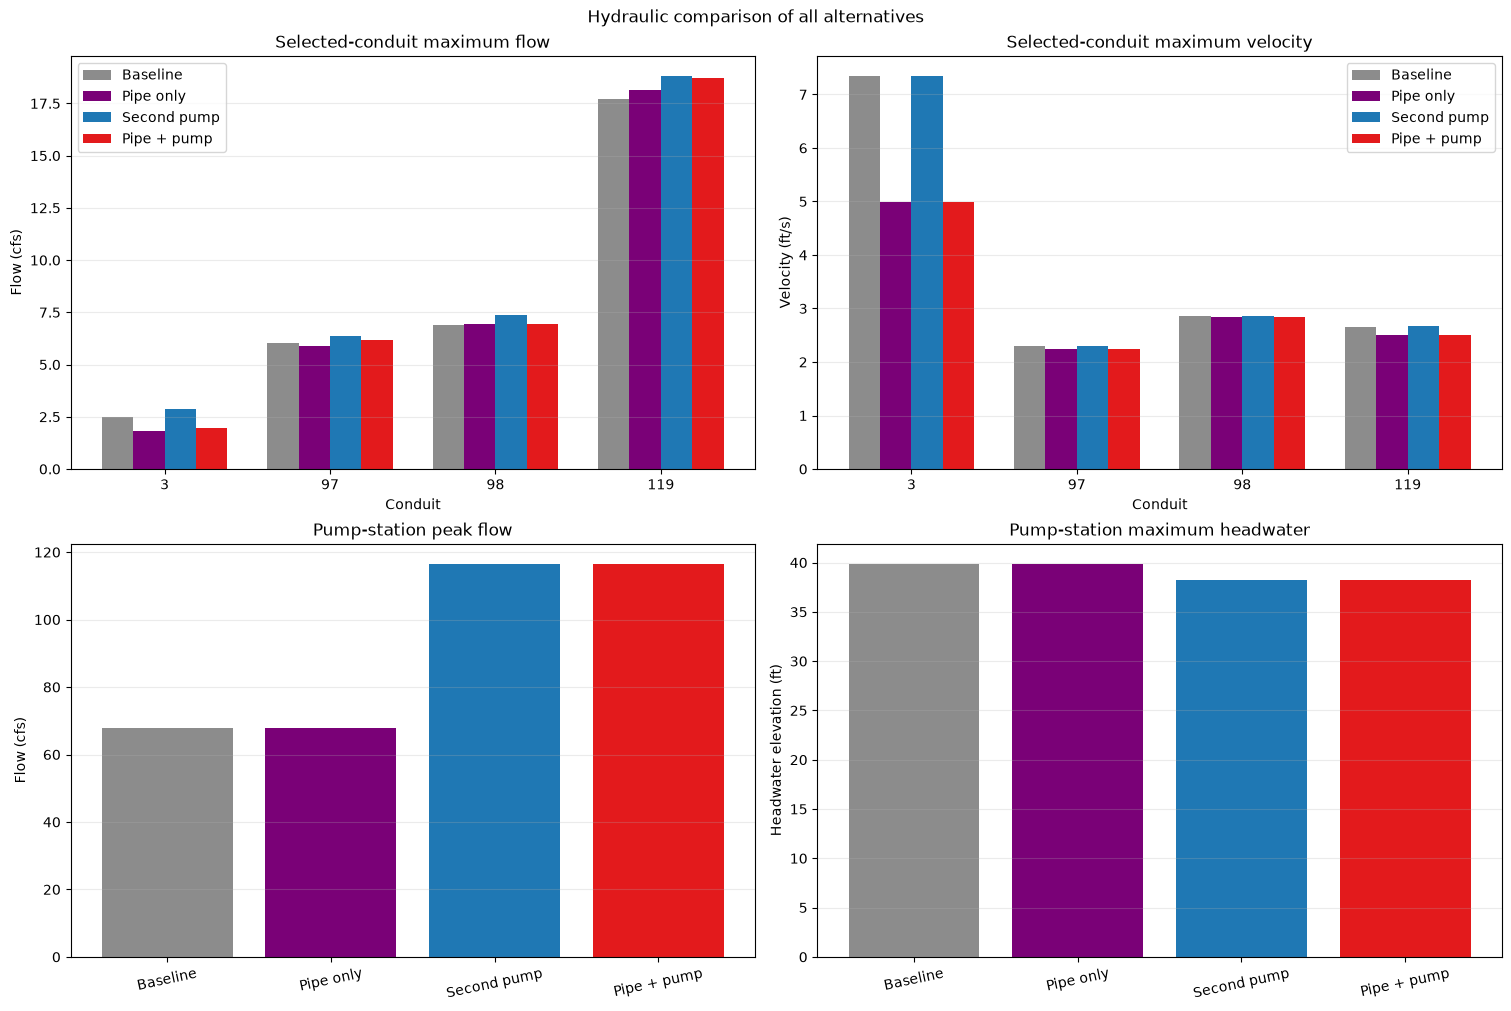

In [8]:
pipe_compute = compute_plan_stage(
    PIPE_PLAN, "Pipe-only alternative", inputs_changed=pipe_inputs_changed
)
pump_compute = compute_plan_stage(
    PUMP_PLAN, "Second-pump alternative", inputs_changed=pump_inputs_changed
)
combined_compute = compute_plan_stage(
    COMBINED_PLAN,
    "Combined pipe-and-pump alternative",
    inputs_changed=combined_inputs_changed,
)

hydraulic_scenarios = (
    (BASELINE_PLAN, "Baseline"),
    (PIPE_PLAN, "Pipe only"),
    (PUMP_PLAN, "Second pump"),
    (COMBINED_PLAN, "Pipe + pump"),
)
qv_frames = []
for plan, condition in hydraulic_scenarios:
    plan_qv = baseline_qv.copy() if plan == BASELINE_PLAN else pipe_qv_summary(plan)
    plan_qv = plan_qv[plan_qv["conduit"].isin(SELECTED_CONDUITS)].copy()
    plan_qv["condition"] = condition
    plan_qv["chain_order"] = plan_qv["conduit"].map(
        {name: order for order, name in enumerate(SELECTED_CONDUITS)}
    )
    qv_frames.append(plan_qv)
qv_comparison = pd.concat(qv_frames, ignore_index=True).sort_values(
    ["chain_order", "condition"]
)
qv_comparison.to_csv(WORK_ROOT / "conduit_hydraulic_comparison.csv", index=False)
display(qv_comparison)

pump_rows = []
for plan, condition in hydraulic_scenarios:
    pump_ts = HdfPump.get_pump_station_timeseries(plan, PUMP_GROUP_NAME)
    pump_rows.append({
        "condition": condition,
        "peak_flow_cfs": float(pump_ts.sel(variable="Flow").max()),
        "max_headwater_ft": float(pump_ts.sel(variable="Stage HW").max()),
    })
pump_comparison = pd.DataFrame(pump_rows)
pump_comparison.to_csv(WORK_ROOT / "pump_performance_comparison.csv", index=False)
display(pump_comparison)

positions = np.arange(len(SELECTED_CONDUITS))
width = 0.19
scenario_colors = {
    "Baseline": "#8c8c8c", "Pipe only": "#7a0177",
    "Second pump": "#1f78b4", "Pipe + pump": "#e31a1c",
}
fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)
for index, (_, condition) in enumerate(hydraulic_scenarios):
    values = qv_comparison[qv_comparison["condition"] == condition].set_index(
        "conduit"
    ).loc[SELECTED_CONDUITS]
    offset = (index - 1.5) * width
    axes[0, 0].bar(
        positions + offset, values["max_abs_flow_cfs"], width,
        color=scenario_colors[condition], label=condition,
    )
    axes[0, 1].bar(
        positions + offset, values["max_abs_velocity_ft_s"], width,
        color=scenario_colors[condition], label=condition,
    )
for axis, title, ylabel in (
    (axes[0, 0], "Selected-conduit maximum flow", "Flow (cfs)"),
    (axes[0, 1], "Selected-conduit maximum velocity", "Velocity (ft/s)"),
):
    axis.set_xticks(positions, SELECTED_CONDUITS)
    axis.set_xlabel("Conduit")
    axis.set_ylabel(ylabel)
    axis.set_title(title)
    axis.grid(axis="y", alpha=0.25)
    axis.legend()
pump_positions = np.arange(len(pump_comparison))
pump_colors = [scenario_colors[value] for value in pump_comparison["condition"]]
axes[1, 0].bar(pump_positions, pump_comparison["peak_flow_cfs"], color=pump_colors)
axes[1, 0].set_ylabel("Flow (cfs)")
axes[1, 0].set_title("Pump-station peak flow")
axes[1, 1].bar(pump_positions, pump_comparison["max_headwater_ft"], color=pump_colors)
axes[1, 1].set_ylabel("Headwater elevation (ft)")
axes[1, 1].set_title("Pump-station maximum headwater")
for axis in axes[1, :]:
    axis.set_xticks(pump_positions, pump_comparison["condition"], rotation=12)
    axis.grid(axis="y", alpha=0.25)
fig.suptitle("Hydraulic comparison of all alternatives")
fig.savefig(WORK_ROOT / "hydraulic_alternative_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Generate separate BenefitArea rasters and polygons

In [9]:
polygon_tolerance = terrain_resolution if SIMPLIFY_POLYGON_EDGES else None
benefit_config = BenefitAreaConfig(
    pre_plan_number=BASELINE_PLAN,
    terrain_tif=terrain_tif,
    terrain_name="Terrain (1)",
    include_wse=INCLUDE_WSE,
    flood_min_depth=FLOOD_MIN_DEPTH_FT,
    benefit_min_depth=BENEFIT_MIN_DEPTH_FT,
    minimum_region_pixels=MINIMUM_REGION_PIXELS,
    polygon_output=True,
    polygon_simplify_tolerance=polygon_tolerance,
)

scenario_outputs = {}
for scenario, plan, output_dir in (
    ("Pipe-only", PIPE_PLAN, PIPE_OUTPUT_DIR),
    ("Second pump", PUMP_PLAN, PUMP_OUTPUT_DIR),
    ("Pipe + pump", COMBINED_PLAN, COMBINED_OUTPUT_DIR),
):
    scenario_outputs[scenario] = RasProcess.store_maps(
        plan_number=plan,
        output_path=output_dir,
        profile="Max",
        benefit_area=benefit_config,
        ras_version=RAS_VERSION,
        timeout=1800,
    )
    print(f"{scenario}: {scenario_outputs[scenario]['benefit_area'][0]}")

2026-07-18 09:16:41 - rasterio._env - WARNING - CPLE_AppDefined in Depth (Max).Terrain (1).Davis_terrain2.tif: TIFFFetchNormalTag:ASCII value for tag "GDALNoDataValue" contains null byte in value; value incorrectly truncated during reading due to implementation limitations


C:\Users\bill\.config\superpowers\worktrees\ras-commander\codex-benefit-area\.venv\Lib\site-packages\rasterio\__init__.py:379: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
2026-07-18 09:16:41 - rasterio._env - WARNING - CPLE_AppDefined in TIFFFetchNormalTag:ASCII value for tag "GDALNoDataValue" contains null byte in value; value incorrectly truncated during reading due to implementation limitations


2026-07-18 09:16:44 - rasterio._env - WARNING - CPLE_AppDefined in DeprecationWarning: 'Memory' driver is deprecated since GDAL 3.11. Use 'MEM' onwards. Further messages of this type will be suppressed.


2026-07-18 09:16:44 - pyogrio._io - INFO - Created 1 records


2026-07-18 09:16:44 - ras_commander.RasBenefits - INFO - BenefitArea complete: classes=1; cells=13056; polygon=True


...

Second pump: C:\Users\bill\.config\superpowers\worktrees\ras-commander\codex-benefit-area\working\612_benefit_area_analysis\Davis_612_benefit_area\BenefitArea\p02-to-p03-second-pump\Benefit Area (Max).p02-to-p03.tif


2026-07-18 09:16:59 - pyogrio._io - INFO - Created 3 records


2026-07-18 09:16:59 - ras_commander.RasBenefits - INFO - BenefitArea complete: classes=3; cells=17866; polygon=True


2026-07-18 09:16:59 - ras_commander.RasProcess - INFO - BenefitArea stored-map workflow complete: pre=p02; post=p04; wse=False; filter=16; polygon=True


Pipe + pump: C:\Users\bill\.config\superpowers\worktrees\ras-commander\codex-benefit-area\working\612_benefit_area_analysis\Davis_612_benefit_area\BenefitArea\p02-to-p04-pipe-and-pump-upgrade\Benefit Area (Max).p02-to-p04.tif


## 9. Screen for adverse depth increases

Adverse impact is evaluated independently from benefit classification. A cell qualifies when proposed minus baseline maximum depth is at least **0.05 ft**. The same optional four-connected **16-cell** region filter is applied. Maps explicitly show adverse regions or state that no adverse impact meets this threshold.

In [10]:
CATEGORY_NAMES = {1: "No Change", 2: "Partially Benefited", 3: "Fully Benefited"}


def polygonize_mask(mask: np.ndarray, transform, crs) -> gpd.GeoDataFrame:
    geometries = [
        shape(geometry)
        for geometry, value in shapes(
            mask.astype(np.uint8), mask=mask, transform=transform
        )
        if value == 1
    ]
    return gpd.GeoDataFrame(geometry=geometries, crs=crs)


def analyze_scenario(scenario: str, outputs: dict) -> dict:
    pre_path = outputs["benefit_source_pre_depth"][0]
    post_path = outputs["benefit_source_post_depth"][0]
    benefit_path = outputs["benefit_area"][0]
    polygon_path = outputs["benefit_area_polygon"][0]
    pre, pre_extent, pre_crs, transform, profile = read_map_raster(pre_path)
    post, post_extent, post_crs, post_transform, _ = read_map_raster(post_path)
    benefit, benefit_extent, benefit_crs, _, _ = read_map_raster(benefit_path, mask_zero=True)
    if not (pre_crs == post_crs == benefit_crs) or transform != post_transform:
        raise ValueError(f"{scenario}: depth and BenefitArea rasters are not aligned")

    valid = ~np.ma.getmaskarray(pre) & ~np.ma.getmaskarray(post)
    delta = np.asarray(post) - np.asarray(pre)
    adverse = RasBenefits.classify_adverse_depth_arrays(
        pre,
        post,
        adverse_min_depth=ADVERSE_IMPACT_THRESHOLD_FT,
        minimum_region_pixels=MINIMUM_REGION_PIXELS,
    ) == 1
    adverse_path = Path(benefit_path).with_name(
        Path(benefit_path).stem.replace("Benefit Area", "Adverse Depth") + ".tif"
    )
    adverse_profile = profile.copy()
    adverse_profile.update(dtype="uint8", count=1, nodata=0, compress="deflate")
    with rasterio.open(adverse_path, "w", **adverse_profile) as dst:
        dst.write(adverse.astype(np.uint8), 1)
        dst.update_tags(
            adverse_depth_threshold_ft=ADVERSE_IMPACT_THRESHOLD_FT,
            minimum_region_pixels=(
                "none" if MINIMUM_REGION_PIXELS is None else MINIMUM_REGION_PIXELS
            ),
        )

    with rasterio.open(benefit_path) as src:
        benefit_values = src.read(1)
        pixel_area = abs(src.transform.a * src.transform.e)
    benefit_regions = polygonize_mask(
        np.isin(benefit_values, [2, 3]), transform, benefit_crs
    )
    adverse_regions = polygonize_mask(adverse, transform, benefit_crs)
    buildings = building_footprints.to_crs(benefit_crs)
    benefited_buildings = buildings.iloc[0:0].copy()
    adverse_buildings = buildings.iloc[0:0].copy()
    if not benefit_regions.empty:
        benefited_buildings = buildings[
            buildings.intersects(benefit_regions.geometry.union_all())
        ].copy()
    if not adverse_regions.empty:
        adverse_buildings = buildings[
            buildings.intersects(adverse_regions.geometry.union_all())
        ].copy()
    statistics = {
        CATEGORY_NAMES[code]: int(np.count_nonzero(benefit_values == code))
        for code in CATEGORY_NAMES
    }
    adverse_cells = int(adverse.sum())
    result = {
        "scenario": scenario,
        "pre": pre,
        "post": post,
        "delta": delta,
        "benefit": benefit,
        "adverse": adverse,
        "extent": benefit_extent,
        "crs": benefit_crs,
        "polygons": gpd.read_file(polygon_path).to_crs(benefit_crs),
        "buildings": buildings,
        "benefited_buildings": benefited_buildings,
        "adverse_buildings": adverse_buildings,
        "adverse_path": adverse_path,
        "partial_acres": statistics["Partially Benefited"] * pixel_area / 43560.0,
        "full_acres": statistics["Fully Benefited"] * pixel_area / 43560.0,
        "adverse_cells": adverse_cells,
        "adverse_acres": adverse_cells * pixel_area / 43560.0,
        "max_adverse_increase_ft": (
            float(np.max(delta[adverse])) if adverse_cells else 0.0
        ),
        "benefited_building_count": len(benefited_buildings),
        "adverse_building_count": len(adverse_buildings),
    }
    return result


analyses = {
    scenario: analyze_scenario(scenario, outputs)
    for scenario, outputs in scenario_outputs.items()
}
impact_summary = pd.DataFrame([
    {
        "scenario": result["scenario"],
        "partial_benefit_acres": result["partial_acres"],
        "full_benefit_acres": result["full_acres"],
        "adverse_acres": result["adverse_acres"],
        "maximum_adverse_increase_ft": result["max_adverse_increase_ft"],
        "buildings_intersecting_benefit": result["benefited_building_count"],
        "buildings_intersecting_adverse": result["adverse_building_count"],
        "adverse_threshold_ft": ADVERSE_IMPACT_THRESHOLD_FT,
        "minimum_region_pixels": MINIMUM_REGION_PIXELS,
    }
    for result in analyses.values()
])
impact_summary.to_csv(WORK_ROOT / "benefit_and_adverse_summary.csv", index=False)
display(impact_summary)

C:\Users\bill\AppData\Local\Temp\ipykernel_10232\3547882400.py:49: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  benefit_values = src.read(1)


C:\Users\bill\AppData\Local\Temp\ipykernel_10232\3547882400.py:49: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  benefit_values = src.read(1)


C:\Users\bill\AppData\Local\Temp\ipykernel_10232\3547882400.py:49: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  benefit_values = src.read(1)


,scenario,partial_benefit_acres,full_benefit_acres,adverse_acres,maximum_adverse_increase_ft,buildings_intersecting_benefit,buildings_intersecting_adverse,adverse_threshold_ft,minimum_region_pixels
0,Pipe-only,0.000000,0.000000,0.000000,0.000000,0,0,0.05,16
1,Second pump,12.568588,2.349447,5.730359,0.583683,34,0,0.05,16
2,Pipe + pump,12.396677,2.425852,5.730359,0.583088,34,0,0.05,16


At the selected thresholds, the adverse-classified area for both pump alternatives is located downstream of the pump station, a spatial pattern consistent with the modeled conveyance change. The pipe-only alternative does not produce qualifying BenefitArea cells; within this example, the limited response may reflect the selected segments, existing pipe capacity, or the relative influence of pump capacity. The comparison is intended to demonstrate programmatic generation of BenefitArea rasters and polygons for alternatives with and without measurable mapped benefit, rather than to establish a preferred design.

## 10. Map benefits, adverse impacts, and changed assets

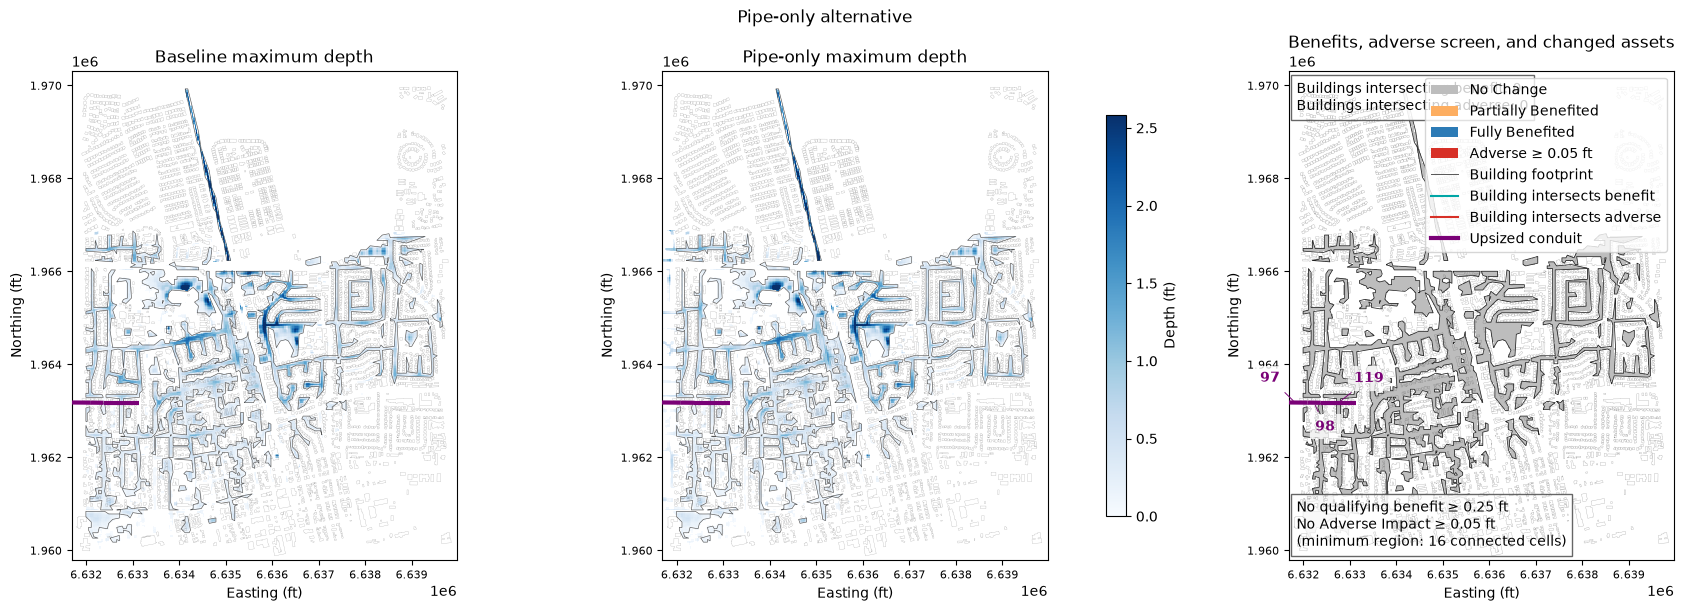

Saved C:\Users\bill\.config\superpowers\worktrees\ras-commander\codex-benefit-area\working\612_benefit_area_analysis\pipe_benefit_and_adverse_maps.png


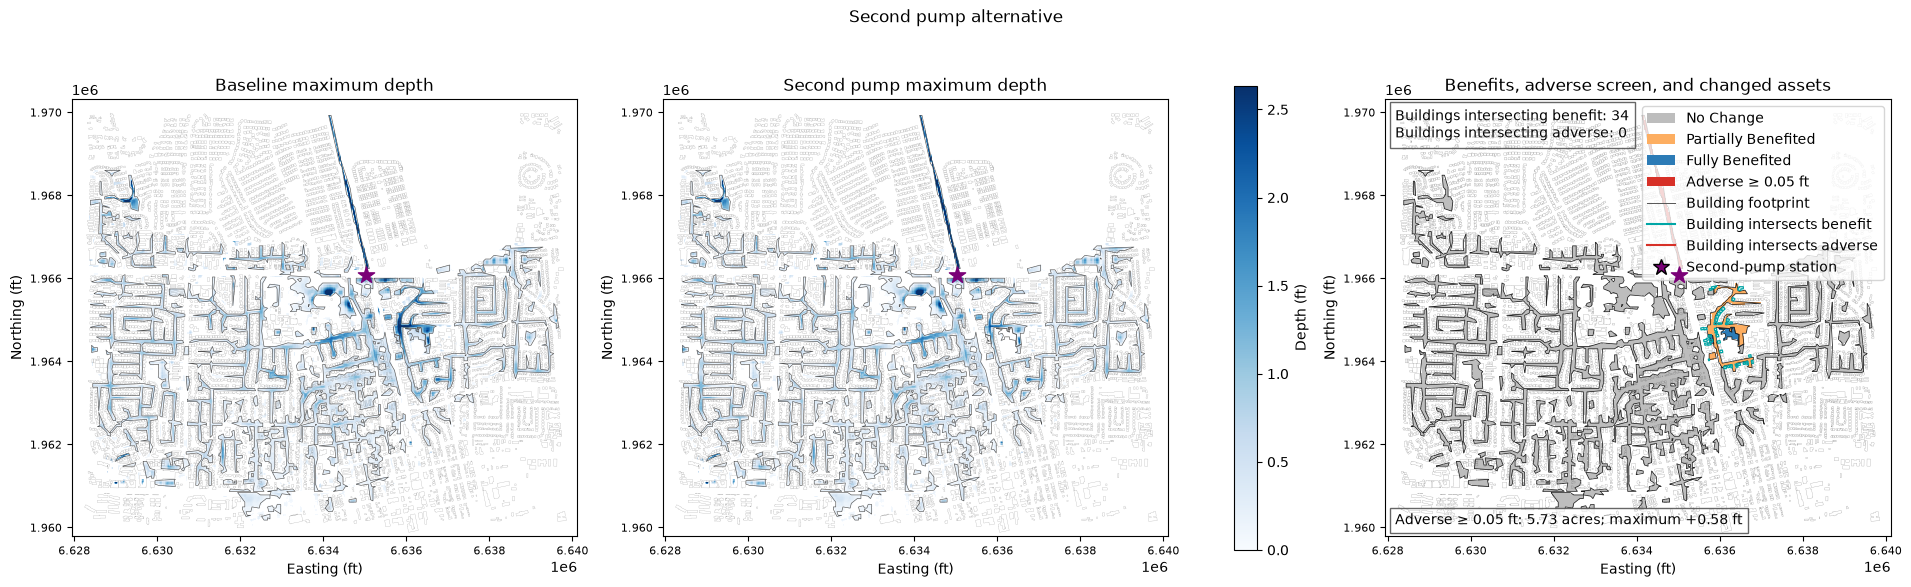

Saved C:\Users\bill\.config\superpowers\worktrees\ras-commander\codex-benefit-area\working\612_benefit_area_analysis\second_pump_benefit_and_adverse_maps.png


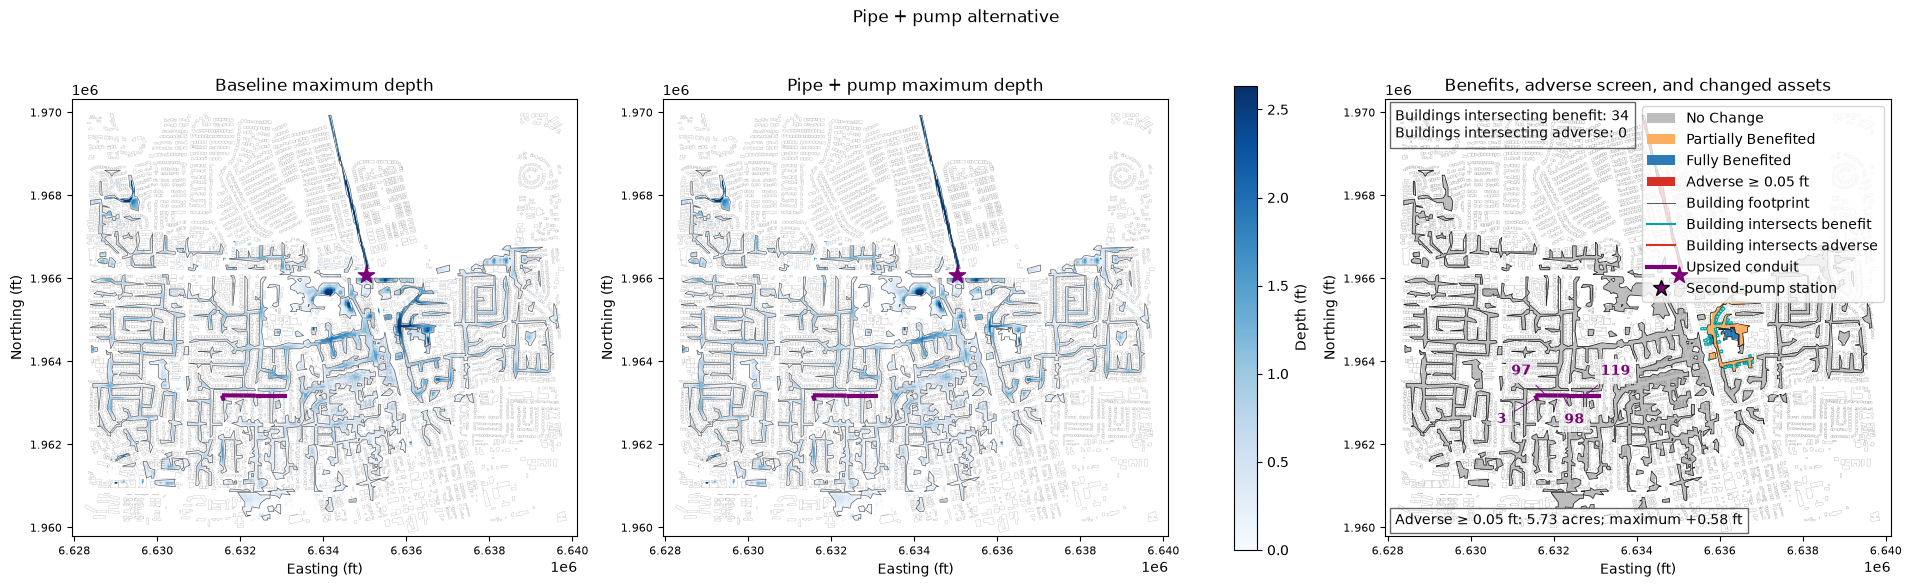

Saved C:\Users\bill\.config\superpowers\worktrees\ras-commander\codex-benefit-area\working\612_benefit_area_analysis\combined_benefit_and_adverse_maps.png


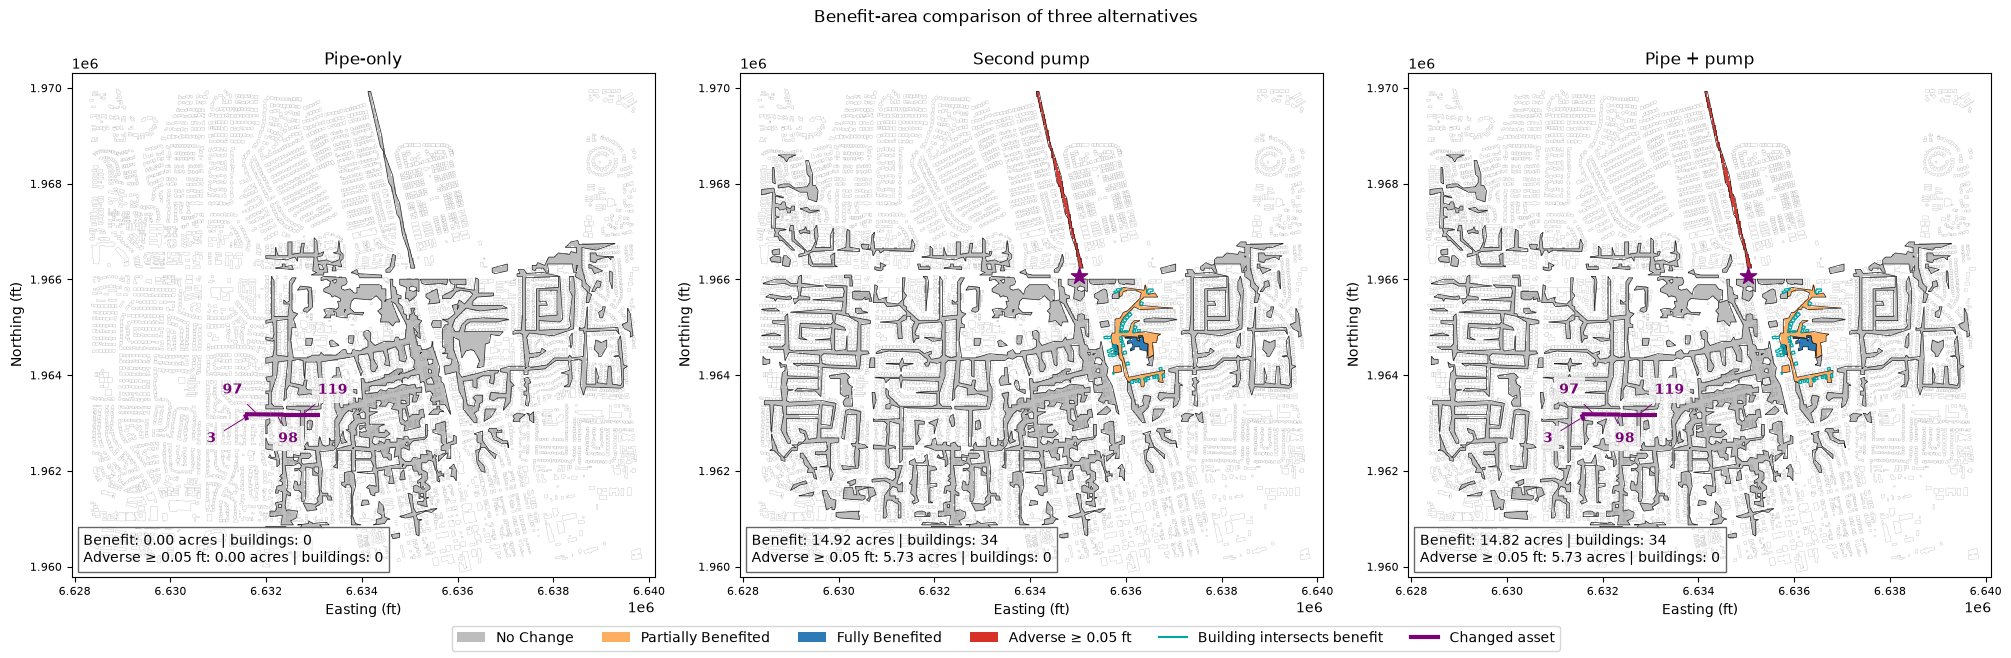

Saved C:\Users\bill\.config\superpowers\worktrees\ras-commander\codex-benefit-area\working\612_benefit_area_analysis\scenario_benefit_comparison.png


In [11]:
benefit_colors = ["#bdbdbd", "#fdae61", "#2c7bb6"]
benefit_cmap = ListedColormap(benefit_colors)
benefit_norm = BoundaryNorm([0.5, 1.5, 2.5, 3.5], benefit_cmap.N)


def draw_changed_assets(
    axis,
    result_crs,
    *,
    pipe_assets: gpd.GeoDataFrame | None = None,
    pump_point_assets: gpd.GeoDataFrame | None = None,
    annotate_pipes: bool = False,
):
    if pipe_assets is not None:
        pipes = pipe_assets.to_crs(result_crs)
        pipes.plot(ax=axis, color="#7a0177", linewidth=3.0, zorder=7)
        if annotate_pipes:
            map_label_offsets = {
                "3": (-25, -18), "97": (-18, 15),
                "98": (8, -20), "119": (22, 15),
            }
            for row in pipes.itertuples():
                midpoint = row.Polyline.interpolate(0.5, normalized=True)
                axis.annotate(
                    row.conduit, xy=(midpoint.x, midpoint.y),
                    xytext=map_label_offsets[row.conduit],
                    textcoords="offset points", ha="center", color="#7a0177",
                    weight="bold",
                    bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.82},
                    arrowprops={"arrowstyle": "-", "color": "#7a0177", "linewidth": 0.7},
                )
    if pump_point_assets is not None:
        pump_point_assets.to_crs(result_crs).plot(
            ax=axis, color="#7a0177", marker="*", markersize=150, zorder=8
        )


def plot_scenario_maps(
    result: dict,
    output_name: str,
    *,
    pipe_assets: gpd.GeoDataFrame | None = None,
    pump_point_assets: gpd.GeoDataFrame | None = None,
):
    min_x, min_y, max_x, max_y = result["polygons"].total_bounds
    map_buildings = result["buildings"].cx[min_x:max_x, min_y:max_y]
    positive_depths = np.concatenate([
        result["pre"].compressed(), result["post"].compressed()
    ])
    positive_depths = positive_depths[positive_depths > 0]
    depth_vmax = float(np.percentile(positive_depths, 99.5)) if positive_depths.size else 1.0
    fig, axes = plt.subplots(1, 3, figsize=(19, 6), constrained_layout=True)
    depth_image = None
    for axis, values, title in (
        (axes[0], result["pre"], "Baseline maximum depth"),
        (axes[1], result["post"], f"{result['scenario']} maximum depth"),
    ):
        depth_image = axis.imshow(
            values, extent=result["extent"], origin="upper", cmap="Blues",
            vmin=0, vmax=depth_vmax, interpolation="nearest"
        )
        map_buildings.boundary.plot(
            ax=axis, color="#555555", linewidth=0.18, alpha=0.55, zorder=3
        )
        result["polygons"].boundary.plot(ax=axis, color="#555555", linewidth=0.45)
        draw_changed_assets(
            axis, result["crs"], pipe_assets=pipe_assets,
            pump_point_assets=pump_point_assets,
        )
        axis.set_title(title)

    axes[2].imshow(
        result["benefit"], extent=result["extent"], origin="upper",
        cmap=benefit_cmap, norm=benefit_norm, interpolation="nearest"
    )
    adverse_display = np.ma.masked_where(~result["adverse"], result["adverse"])
    axes[2].imshow(
        adverse_display, extent=result["extent"], origin="upper",
        cmap=ListedColormap(["#d73027"]), interpolation="nearest", alpha=0.9
    )
    result["polygons"].boundary.plot(ax=axes[2], color="#202020", linewidth=0.55)
    map_buildings.boundary.plot(
        ax=axes[2], color="#555555", linewidth=0.2, alpha=0.6, zorder=4
    )
    if not result["benefited_buildings"].empty:
        result["benefited_buildings"].plot(
            ax=axes[2], facecolor="none", edgecolor="#00a6a6",
            linewidth=0.9, zorder=5
        )
    if not result["adverse_buildings"].empty:
        result["adverse_buildings"].plot(
            ax=axes[2], facecolor="none", edgecolor="#d73027",
            linewidth=1.1, zorder=6
        )
    draw_changed_assets(
        axes[2], result["crs"], pipe_assets=pipe_assets,
        pump_point_assets=pump_point_assets, annotate_pipes=True,
    )
    axes[2].set_title("Benefits, adverse screen, and changed assets")

    if result["adverse_cells"]:
        adverse_note = (
            f"Adverse ≥ {ADVERSE_IMPACT_THRESHOLD_FT:.2f} ft: "
            f"{result['adverse_acres']:.2f} acres; "
            f"maximum +{result['max_adverse_increase_ft']:.2f} ft"
        )
    else:
        filter_note = (
            "no pixel filter" if MINIMUM_REGION_PIXELS is None
            else f"minimum region: {MINIMUM_REGION_PIXELS} connected cells"
        )
        adverse_note = (
            f"No Adverse Impact ≥ {ADVERSE_IMPACT_THRESHOLD_FT:.2f} ft\n({filter_note})"
        )
    benefit_acres = result["partial_acres"] + result["full_acres"]
    benefit_note = (
        "" if benefit_acres
        else f"No qualifying benefit ≥ {BENEFIT_MIN_DEPTH_FT:.2f} ft\n"
    )
    axes[2].text(
        0.02, 0.02, benefit_note + adverse_note, transform=axes[2].transAxes,
        ha="left", va="bottom", bbox={"facecolor": "white", "edgecolor": "#555555", "alpha": 0.9}
    )

    building_note = (
        f"Buildings intersecting benefit: {result['benefited_building_count']:,}\n"
        f"Buildings intersecting adverse: {result['adverse_building_count']:,}"
    )
    axes[2].text(
        0.02, 0.98, building_note, transform=axes[2].transAxes,
        ha="left", va="top",
        bbox={"facecolor": "white", "edgecolor": "#555555", "alpha": 0.9},
    )

    padding_x = max((max_x - min_x) * 0.04, terrain_resolution)
    padding_y = max((max_y - min_y) * 0.04, terrain_resolution)
    for axis in axes:
        axis.set_xlim(min_x - padding_x, max_x + padding_x)
        axis.set_ylim(min_y - padding_y, max_y + padding_y)
        axis.set_aspect("equal")
        axis.set_xlabel("Easting (ft)")
        axis.set_ylabel("Northing (ft)")
        axis.tick_params(labelsize=8)
    fig.colorbar(depth_image, ax=axes[:2], label="Depth (ft)", shrink=0.82)
    legend = [
        Patch(facecolor=color, edgecolor="none", label=CATEGORY_NAMES[code])
        for code, color in zip((1, 2, 3), benefit_colors)
    ]
    legend.append(Patch(facecolor="#d73027", edgecolor="none", label=f"Adverse ≥ {ADVERSE_IMPACT_THRESHOLD_FT:.2f} ft"))
    legend.append(Line2D([0], [0], color="#555555", linewidth=0.7, label="Building footprint"))
    legend.append(Line2D([0], [0], color="#00a6a6", linewidth=1.5, label="Building intersects benefit"))
    legend.append(Line2D([0], [0], color="#d73027", linewidth=1.5, label="Building intersects adverse"))
    if pipe_assets is not None:
        legend.append(Line2D([0], [0], color="#7a0177", linewidth=3, label="Upsized conduit"))
    if pump_point_assets is not None:
        legend.append(Line2D(
            [0], [0], marker="*", color="none", markerfacecolor="#7a0177",
            markersize=12, label="Second-pump station",
        ))
    axes[2].legend(handles=legend, loc="upper right")
    fig.suptitle(f"{result['scenario']} alternative")
    path = WORK_ROOT / output_name
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {path}")


plot_scenario_maps(
    analyses["Pipe-only"],
    "pipe_benefit_and_adverse_maps.png",
    pipe_assets=changed_pipe_assets,
)
plot_scenario_maps(
    analyses["Second pump"],
    "second_pump_benefit_and_adverse_maps.png",
    pump_point_assets=pump_assets,
)
plot_scenario_maps(
    analyses["Pipe + pump"],
    "combined_benefit_and_adverse_maps.png",
    pipe_assets=changed_pipe_assets,
    pump_point_assets=pump_assets,
)

scenario_asset_map = {
    "Pipe-only": {"pipe_assets": changed_pipe_assets},
    "Second pump": {"pump_point_assets": pump_assets},
    "Pipe + pump": {
        "pipe_assets": changed_pipe_assets,
        "pump_point_assets": pump_assets,
    },
}
comparison_results = [analyses[name] for name in scenario_asset_map]
all_bounds = np.asarray([result["polygons"].total_bounds for result in comparison_results])
comparison_bounds = (
    float(all_bounds[:, 0].min()), float(all_bounds[:, 1].min()),
    float(all_bounds[:, 2].max()), float(all_bounds[:, 3].max()),
)
comp_min_x, comp_min_y, comp_max_x, comp_max_y = comparison_bounds
comp_pad_x = max((comp_max_x - comp_min_x) * 0.04, terrain_resolution)
comp_pad_y = max((comp_max_y - comp_min_y) * 0.04, terrain_resolution)
fig, axes = plt.subplots(1, 3, figsize=(20, 6.5), constrained_layout=True)
for axis, result in zip(axes, comparison_results):
    axis.imshow(
        result["benefit"], extent=result["extent"], origin="upper",
        cmap=benefit_cmap, norm=benefit_norm, interpolation="nearest",
    )
    axis.imshow(
        np.ma.masked_where(~result["adverse"], result["adverse"]),
        extent=result["extent"], origin="upper",
        cmap=ListedColormap(["#d73027"]), interpolation="nearest", alpha=0.9,
    )
    result["polygons"].boundary.plot(ax=axis, color="#202020", linewidth=0.5)
    result["buildings"].cx[
        comp_min_x:comp_max_x, comp_min_y:comp_max_y
    ].boundary.plot(ax=axis, color="#555555", linewidth=0.18, alpha=0.55, zorder=4)
    if not result["benefited_buildings"].empty:
        result["benefited_buildings"].plot(
            ax=axis, facecolor="none", edgecolor="#00a6a6", linewidth=0.9, zorder=5
        )
    if not result["adverse_buildings"].empty:
        result["adverse_buildings"].plot(
            ax=axis, facecolor="none", edgecolor="#d73027", linewidth=1.1, zorder=6
        )
    draw_changed_assets(
        axis, result["crs"], annotate_pipes=True,
        **scenario_asset_map[result["scenario"]],
    )
    total_benefit = result["partial_acres"] + result["full_acres"]
    axis.text(
        0.02, 0.02,
        f"Benefit: {total_benefit:.2f} acres | buildings: {result['benefited_building_count']:,}\n"
        f"Adverse ≥ {ADVERSE_IMPACT_THRESHOLD_FT:.2f} ft: {result['adverse_acres']:.2f} acres | "
        f"buildings: {result['adverse_building_count']:,}",
        transform=axis.transAxes, ha="left", va="bottom",
        bbox={"facecolor": "white", "edgecolor": "#555555", "alpha": 0.9},
    )
    axis.set_xlim(comp_min_x - comp_pad_x, comp_max_x + comp_pad_x)
    axis.set_ylim(comp_min_y - comp_pad_y, comp_max_y + comp_pad_y)
    axis.set_aspect("equal")
    axis.set_title(result["scenario"])
    axis.set_xlabel("Easting (ft)")
    axis.set_ylabel("Northing (ft)")
    axis.tick_params(labelsize=8)
comparison_legend = [
    Patch(facecolor=color, edgecolor="none", label=CATEGORY_NAMES[code])
    for code, color in zip((1, 2, 3), benefit_colors)
]
comparison_legend.extend([
    Patch(facecolor="#d73027", edgecolor="none", label=f"Adverse ≥ {ADVERSE_IMPACT_THRESHOLD_FT:.2f} ft"),
    Line2D([0], [0], color="#00a6a6", linewidth=1.5, label="Building intersects benefit"),
    Line2D([0], [0], color="#7a0177", linewidth=3, label="Changed asset"),
])
fig.legend(handles=comparison_legend, loc="outside lower center", ncol=6)
fig.suptitle("Benefit-area comparison of three alternatives")
comparison_path = WORK_ROOT / "scenario_benefit_comparison.png"
fig.savefig(comparison_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {comparison_path}")

## Re-run behavior

- Project extraction is skipped when the working project exists.
- Each HEC-RAS plan compute is mandatory, but a completed result is reused when its scenario inputs are unchanged.
- Changing a conduit target or pump curve invalidates the affected independent and combined scenarios.
- BenefitArea, adverse-impact screening, tables, figures, rasters, and polygons are regenerated on every notebook run.
- Delete `working/612_benefit_area_analysis` to force a complete extraction and hydraulic rerun.